# Energy model: fresh data, configurable local interactions and accommodation sweep

Train an interpretable model of **mean curvature** from exclusive cell identities. Every identity has a preferred residual curvature. The source and recipient panels are explicit settings. The current reference experiment permits every identity, including Unassigned, in both panels. The current experiment uses the fraction of neighbors of each source identity at **one hop**, excluding the center; literal presence is also selectable. All cells participate in shared mechanical accommodation.

For center identity \(A_i\) and source panel \(S\) and recipient panel \(T\),
\[
u_i=a_{A_i}+\mathbf1(A_i\in T)\sum_{B\in S}\beta_{A_iB}f(x_{iB}),\qquad
(I+\gamma L)\hat h=u,\qquad \hat H_i=b_g+\hat h_i.
\]
The graph Laplacian \(L\) uses equal cell weights. The spatially constant baseline \(b_g\) is fitted separately using training organoids only. At each fixed nonnegative accommodation \(\gamma\), fit all center preferences and allowed pair amplitudes jointly by penalized least squares. Here x is the one-hop neighbor fraction and f(x)=x for linear interactions, or 1[x>0] for presence. For linear all-to-all fractions, a row-wide amplitude shift can be canceled by the center preference: the unchanged ridge penalties choose a numerical split, not an independently identifiable biological split. There are no learned activation thresholds, N-dependent local coefficients, cell-area weights or measured-neighbor inputs. Coefficients \(a_A\) are **preferred residual curvatures**, not measured native cell shapes.

This notebook loads the original dataset directly: **no reference run supplies hidden settings**. For a matched comparison, `PREPARED_INPUT_RUN` copies exact saved fold inputs and baselines after checking that the exposed data settings, memberships and raw graphs agree. Setting it to `None` fits new baselines. Defaults select day4/day4.5 data, five ordinary folds, and sphericity below 0.93. Otherwise eligible organoids at or above 0.93 form a separate spherical validation cohort. They never fit preprocessing, the baseline, coefficients or penalties and never select accommodation. Invalid metadata and other quality exclusions do not enter that cohort.

All gamma checkpoints, exact memberships, raw data, fitted transformations, baselines, settings and per-organoid validation scores are saved under `training_results/energy_model_training/<tag>_<timestamp>`. `energy_model_evaluation.ipynb` loads these artifacts and plots MSE and coefficients against accommodation. An optional depth-1 plain GIN (disabled for the folded energy-only run) can be trained on the same saved physical residuals and outer membership, with no global features and no FiLM. Its epoch count uses the same inner training holdout as the energy fits; it is then refitted on all ordinary training organoids. Spherical and ordinary outer validation are scoring-only for both models.

In [1]:
from pathlib import Path
import sys
import copy
import json
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from IPython.display import display
PROJECT_ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p/'src/models/gnn.py').is_file())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from src.data.io import load_graph_dataset_from_dir
from src.data.metadata import attach_metadata_to_graphs, load_aux_metadata_for_dir, load_marker_names_from_dir
from src.data.filters import filter_graphs_by_timepoints, filter_graphs_by_blacklist, load_graph_blacklist_from_dir, filter_graphs_by_numeric_metadata, filter_graphs_by_sphericity
from src.data.preprocessing import interpolate_target_outliers_from_neighbors
from src.data.marker_exclusivity import exclusive_markers, EXCLUSIVITY_RULES
from src.models.size_models import seed_all
from src.training.preparation import prepare_fold
from src.training.coupled_fit import graph_samples
from src.training.energy_fit import fit_energy_fixed
from src.training.progress import TrainingProgress
from src.analysis.spatial.regions import distance_regions
from src.artifacts.bundle import save_bundle, load_bundle, graph_membership
from src.artifacts.paths import training_run_path
from src.artifacts.provenance import workflow_fingerprint
from torch_geometric.loader import DataLoader
from src.models.gnn import GINCurvature
from src.inference.predict import predict_targets

## Settings
Every scientific and training option is exposed here, grouped by purpose. `timepoints` is shared by training, ordinary validation and spherical validation. `n_folds=1` is a single holdout; changing it enables organoid-level folds with the same external spherical cohort evaluated separately for each fold. `RUN_TRAINING=False` allows cohort inspection but prevents fitting or writing a training run.

In [2]:
# Execution and output
RUN_TRAINING = True  # Fit and save a new baseline, energy sweep and GIN reference.
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'  # CPU or CUDA float64 energy solves.
SHOW_PROGRESS = True  # Show fold, accommodation value and completed tasks.
PREPARED_INPUT_RUN = 'training_results/energy_model_training/folded_presence_hop1_extended_gamma_20261002_120514'  # Optional completed energy run: copy exact inputs/baselines after checking the explicit data settings; None fits fresh baselines.

SETTINGS = dict(
    # Run identity and dataset
    tag='all_to_all_linear_fraction_hop1_matched',  # Optional purpose label in the output folder.
    dataset='after_cleanup',  # Original graph dataset under training_data/.
    target_indices=[1],  # Mean curvature only; 0 denotes Gaussian curvature in the dataset.
    strict_loading=True,  # Raise on invalid graph files rather than silently skipping them.

    # Shared cohort selection
    timepoints=['day4', 'day4p5', 'day4p5-more'],  # All currently available labels at day 4 or later.
    blacklist=True,  # Exclude blacklisted organoids before making either cohort.
    sphericity_max=.93,  # Ordinary cohort: q<cutoff; spherical validation: q>=cutoff.
    complexity_min=None,  # Optional minimum complexity, applied to both cohorts.
    exclusive_markers=True,  # Required: sequential exclusive fate rules; all-zero is Unassigned.

    # Ordinary train/validation split
    n_folds=5,  # 1: single holdout; larger values: disjoint validation folds.
    val_fraction=.2,  # Ordinary validation fraction when n_folds=1.
    split_seed=42,  # Reproducible organoid membership; spherical organoids are never split into training.

    # Target cleanup (thresholds learned only on ordinary training organoids)
    interpolate_outliers=True,  # Apply the same training-fitted cleanup to all evaluation cohorts.
    outlier_quantiles=[.005, .995],  # Global training quantiles identifying extreme target values.
    outlier_min_neighbors=1,  # Minimum usable neighbors for interpolation.
    outlier_max_hops=2,  # Target cleanup radius, distinct from model interaction radius.
    outlier_interpolation='quadratic',  # Quadratic or mean neighbor interpolation.
    outlier_ridge=.001,  # Quadratic interpolation regularizer.
    reject_farther_outliers=True,  # Reject replacements that worsen outlier severity.
    outlier_fallback='neighbor_mean',  # Fallback for under-supported interpolation.

    # Local model: every identity retains its own center preference
    source_markers=['Agr2', 'AldoB', 'Chroma', 'KI67', 'LGR5', 'Lysozyme', 'Serotonin', 'Unassigned'],  # Identities permitted to contribute one-hop presence signals.
    recipient_markers=['Agr2', 'AldoB', 'Chroma', 'KI67', 'LGR5', 'Lysozyme', 'Serotonin', 'Unassigned'],  # Recipient identities; may overlap with sources for all-to-all interactions.
    activation='linear',  # 'linear': neighbor fraction; 'presence': 1[fraction>0]; no learned activation parameters.
    interaction_radius=1,  # Direct interactions only at one hop; accommodation uses the full graph.
    size_dependent=False,  # Constant local coefficients and accommodation within each fitted model.
    center_response=False,  # No subtraction of a training-reference activation mean.
    min_pair_organoids=20,  # Pair-support reporting threshold; does not silently remove coefficients.

    # Accommodation and coefficient fitting
    gamma_grid=[0., .1, .2, .4, .8, 1.6, 3.2, 6.4, 12.8, 25.6],  # Fit a separate model at each exact fixed value.
    center_ridge=.0001,  # Center-preference penalty in training-target RMS units.
    pair_ridge_grid=[.0001, .001],  # Select shrinkage using only an inner ordinary-training holdout.
    inner_fraction=.2,  # Holdout fraction within ordinary training for selecting pair shrinkage.
    inner_seed=42,  # Same inner membership for every accommodation value.
    solver_rtol=1e-11,  # Relative tolerance of CUDA graph solves.
    blas_threads=4,  # CPU linear-algebra and torch thread count.

    # Plain GIN reference on identical saved residual targets and memberships
    gin_enabled=False,  # Also train the plain GIN comparator; no FiLM or global features.
    gin_depth=1,  # Number of message-passing layers.
    gin_hidden_dim=128,  # Width of GIN hidden layers and prediction head.
    gin_dropout=.1,  # Hidden dropout during training only.
    gin_norm='batch',  # Standard GIN hidden normalization; evaluation uses fixed running statistics.
    gin_residual=True,  # GIN residual connections.
    gin_seed=42,  # Initialization/minibatch seed; fold index is added.
    gin_lr=.0003,  # AdamW learning rate.
    gin_weight_decay=.0001,  # AdamW weight decay.
    gin_batch_size=128,  # Organoids per batch; each organoid receives equal loss weight.
    gin_max_epochs=500,  # Maximum inner-selection epochs.
    gin_patience=50,  # Early stopping on inner organoid-weighted residual MSE.
    gin_min_delta=1e-7,  # Minimum inner-MSE improvement for resetting patience.
    gin_grad_clip=2.,  # Gradient norm limit.
    gin_num_workers=0,  # GIN loader workers.

    # Baseline and residualization
    residualize=True,  # Required: subtract the fitted global baseline before energy fitting.
    baseline_features=['log_num_cells', 'log_surface_area', 'log_volume', 'log_volume_over_area'],  # Baseline inputs only.
    baseline_hidden_dim=64,  # Global baseline MLP width.
    baseline_dropout=.1,  # Global baseline hidden dropout.
    baseline_lr=.0003,  # Baseline AdamW learning rate.
    baseline_weight_decay=.0001,  # Baseline AdamW weight decay.
    baseline_loss='gaussian',  # Baseline training objective.
    baseline_max_epochs=2000,  # Maximum baseline epochs; early stopping monitors training data.
    baseline_patience=30,  # Baseline early-stopping patience.
    baseline_batch_size=128,  # Organoids per baseline batch.
    baseline_num_workers=0,  # Baseline data-loader workers.
    baseline_pin_memory=True,  # Pin baseline loader tensors for CUDA transfers.
    baseline_seed=42,  # Baseline seed; fold index is added for folded training.
)

# Regional evaluation; labels do not enter model inputs
REGION_SETTINGS = dict(
    crypt_max=.75,  # Crypt interior: s<0.75 regardless of neck qualification.
    neck_max=1.1,  # Qualified neck: 0.75<=s<1.1; villus: s>=1.1.
    crypt_marker='LGR5',  # Split crypts by LGR5 presence anywhere in their assigned interior.
    neck_config=dict(
        minimum_crypt_cells=0,  # No extra crypt-size qualification.
        minimum_relative_depth=.05,  # Circumference trough depth threshold.
        plateau_max_range=.10,  # Maximum relative circumference range for a plateau.
        plateau_max_slope=.25,  # Maximum relative plateau slope.
        plateau_exit_rise=.10,  # Required rise after a plateau.
        minimum_window=[.8, 1.2],  # Search interval for a local circumference minimum.
        plateau_window=[.85, 1.15],  # Interval used to test a flat circumference segment.
        smoothing_points=7,  # Odd Savitzky–Golay profile smoothing window.
    ),
)

# Output path; created only when training is enabled
RUN_DIR = training_run_path(PROJECT_ROOT, 'energy_model_training', SETTINGS['tag'])  # New timestamped run; no old run is inherited.

## Load, filter and separate the spherical validation cohort
The existing sphericity convention is \(q=36\pi V^2/A^3\). Apply timepoints, blacklist and any complexity filter first. Split eligible graphs at the sphericity cutoff; nonfinite or invalid area/volume metadata are excluded, not labeled spherical. Print retained counts and fractions by timepoint at every filter. Preserve targets before fold-specific cleanup.

In [3]:
if SETTINGS['target_indices']!=[1] or not SETTINGS['exclusive_markers'] or not SETTINGS['residualize']:
    raise ValueError('This workflow requires mean curvature, exclusive identities and baseline residualization.')
if SETTINGS['activation'] not in ('presence','linear') or SETTINGS['interaction_radius']!=1 or SETTINGS['size_dependent'] or SETTINGS['center_response']:
    raise ValueError('This experiment uses constant, uncentered one-hop presence or linear-fraction interactions.')
gammas=np.asarray(SETTINGS['gamma_grid'],float)
if not len(gammas) or not np.isfinite(gammas).all() or np.any(gammas<0) or np.any(np.diff(gammas)<=0):
    raise ValueError('gamma_grid must be strictly increasing, finite and nonnegative.')
if not np.isfinite(SETTINGS['sphericity_max']) or not 0<SETTINGS['sphericity_max']<=1:
    raise ValueError('A sphericity cutoff in (0,1] is required.')
torch.set_num_threads(SETTINGS['blas_threads'])
data_dir=PROJECT_ROOT/'training_data'/SETTINGS['dataset']
graphs=load_graph_dataset_from_dir(str(data_dir),strict=SETTINGS['strict_loading'],target_indices=SETTINGS['target_indices'])
attach_metadata_to_graphs(graphs,load_aux_metadata_for_dir(str(data_dir)),exclude_keys=None)
marker_names=load_marker_names_from_dir(str(data_dir))
if not marker_names:raise ValueError('Dataset must supply named fate channels.')
identity_names=list(marker_names)+['Unassigned']
sources=SETTINGS['source_markers'];recipients=SETTINGS['recipient_markers']
if not sources or not recipients or len(set(sources))!=len(sources) or len(set(recipients))!=len(recipients) or not (set(sources)|set(recipients))<=set(identity_names):
    raise ValueError('Source and recipient panels must each contain distinct, known identities; overlap is allowed.')
source_indices=[identity_names.index(x) for x in sources]
recipient_indices=[identity_names.index(x) for x in recipients]
available={str(g.meta.get('timepoint')) for g in graphs}
if SETTINGS['timepoints'] is not None and set(SETTINGS['timepoints'])-available:
    raise ValueError(f'Unknown requested timepoints: {set(SETTINGS["timepoints"])-available}')
graphs=filter_graphs_by_timepoints(graphs,SETTINGS['timepoints'],print_summary=True)
if SETTINGS['blacklist']:
    graphs=filter_graphs_by_blacklist(graphs,load_graph_blacklist_from_dir(data_dir),print_summary=True)
if SETTINGS['complexity_min'] is not None:
    graphs=filter_graphs_by_numeric_metadata(graphs,key='complexity',min_value=SETTINGS['complexity_min'],allow_missing=False,print_summary=True)
ordinary,rejected,sphericity=filter_graphs_by_sphericity(graphs,max_sphericity=SETTINGS['sphericity_max'],allow_missing=False,return_rejected=True,return_scores=True,print_summary=True)
q_by_id={str(g.organoid_str):float(q) for g,q in zip(graphs,sphericity)}
spherical=[g for g in rejected if np.isfinite(q_by_id[str(g.organoid_str)]) and q_by_id[str(g.organoid_str)]>=SETTINGS['sphericity_max']]
invalid=[g for g in rejected if not np.isfinite(q_by_id[str(g.organoid_str)])]
print('Separate spherical validation:',len(spherical),'| invalid sphericity metadata excluded:',len(invalid))
for g in ordinary+spherical:
    g.x=torch.as_tensor(exclusive_markers(g.x.cpu().numpy(),marker_names),dtype=g.x.dtype)
    if not torch.isfinite(g.y).all():raise ValueError(f'Nonfinite mean curvature: {g.organoid_str}')
if len(ordinary)<5:raise ValueError('Need at least five ordinary organoids for outer and inner splitting.')
if not spherical:print('No eligible spherical organoids; ordinary validation remains available.')
raw_graphs={str(g.organoid_str):g for g in ordinary+spherical}
if len(raw_graphs)!=len(ordinary)+len(spherical):raise ValueError('Duplicate organoid identifiers.')
cohort=pd.DataFrame([dict(organoid_str=str(g.organoid_str),cohort=role,timepoint=str(g.meta.get('timepoint','unknown')),N=len(g.x),sphericity=q_by_id[str(g.organoid_str)]) for role,group in [('ordinary',ordinary),('spherical',spherical)] for g in group])
display(cohort.groupby(['timepoint','cohort']).agg(organoids=('organoid_str','size'),median_N=('N','median')))

Loaded 1500 graphs; skipped 0.


filter_graphs_by_metadata(key='timepoint'): kept 1210 / 1500 graphs

dataset          timepoint          kept  total     frac
----------------------------------------------------------
20250929         day3p5                0    290    0.000
20250929         day4                342    342    1.000
20250929         day4p5              113    113    1.000
20250929         day4p5-more         477    477    1.000
20251201         day4p5              278    278    1.000
filter_graphs_by_blacklist(n_keys=17): kept 1193 / 1210 graphs

dataset          timepoint          kept  total     frac
----------------------------------------------------------
20250929         day4                330    342    0.965
20250929         day4p5              112    113    0.991
20250929         day4p5-more         475    477    0.996
20251201         day4p5              276    278    0.993
filter_graphs_by_sphericity(max_sphericity=0.93): kept 869 / 1193 graphs

dataset          timepoint          kept  total 

organoids  median_N
timepoint   cohort                        
day4        ordinary         233     318.0
            spherical         97     194.0
day4p5      ordinary         288     425.5
            spherical        100     122.5
day4p5-more ordinary         348     529.0
            spherical        127     213.0

## Define ordinary folds and regional annotations
Spherical organoids are held out from every fold. Ordinary organoids are split once with a saved seed. Regional labels are reconstructed from source crypt distances and circumference profiles. Spherical organoids and ordinary `no_detected_crypt` cells share the reporting category `spherical_or_no_detected_crypt`. Unqualified boundary cells and missing annotations stay in total MSE but are excluded from named regional panels; their counts and original labels remain in the saved annotations.

In [4]:
rng=np.random.default_rng(SETTINGS['split_seed']);order=rng.permutation(len(ordinary))
f=SETTINGS['n_folds']
if not isinstance(f,int) or not 1<=f<=len(ordinary):raise ValueError('Invalid fold count.')
if not 0<SETTINGS['val_fraction']<1:raise ValueError('val_fraction must be between zero and one.')
validation_sets=[order[:max(1,min(len(order)-4,round(len(order)*SETTINGS['val_fraction'])))]] if f==1 else np.array_split(order,f)
splits=[];membership=[]
for fold,val in enumerate(validation_sets):
    train=np.setdiff1d(order,val)
    if len(train)<4 or not len(val):raise ValueError('Each fold needs at least four training organoids and nonempty validation.')
    splits.append(dict(fold=fold,train_indices=train.tolist(),val_indices=val.tolist()))
    membership.append(dict(fold=fold,**graph_membership(train=[ordinary[i] for i in train],validation=[ordinary[i] for i in val]),spherical_validation=[str(g.organoid_str) for g in spherical]))
display(pd.DataFrame([dict(fold=s['fold'],train=len(s['train']),validation=len(s['validation']),spherical_validation=len(s['spherical_validation'])) for s in membership]))
region_rows=[]
for role,group in [('ordinary',ordinary),('spherical',spherical)]:
    for g in group:
        if role=='spherical':
            table=pd.DataFrame(dict(organoid_str=str(g.organoid_str),node=np.arange(len(g.x)),region='spherical_validation',annotation_status='cohort_override'))
        else:
            table=distance_regions(g,data_dir,marker_names=marker_names,**REGION_SETTINGS)
        table['original_region']=table.region
        table['cohort']=role
        table.loc[table.region.isin(['spherical_validation','no_detected_crypt']),'region']='spherical_or_no_detected_crypt'
        table.loc[table.region=='boundary_without_qualified_neck','region']='excluded_boundary'
        region_rows.append(table)
regions=pd.concat(region_rows,ignore_index=True)
display(regions.groupby(['cohort','region']).size().rename('cells').to_frame())
# Optional matched experiment: data settings remain explicit and must agree with the reference.
prepared_reference=None
if PREPARED_INPUT_RUN is not None:
    prepared_reference=Path(PREPARED_INPUT_RUN)
    if not prepared_reference.is_absolute():prepared_reference=PROJECT_ROOT/prepared_reference
    if not (prepared_reference/'complete.json').exists():raise ValueError('Prepared-input reference is incomplete.')
    reference_settings=json.loads((prepared_reference/'settings.json').read_text())
    data_keys=['dataset','target_indices','strict_loading','timepoints','blacklist','sphericity_max','complexity_min','exclusive_markers','n_folds','val_fraction','split_seed','residualize']
    data_keys += [k for k in SETTINGS if k.startswith('baseline_') or k.startswith('outlier_')]
    data_keys += ['interpolate_outliers','reject_farther_outliers']
    mismatch=[k for k in data_keys if SETTINGS[k]!=reference_settings.get(k)]
    if mismatch or REGION_SETTINGS!=reference_settings['region_settings']:raise ValueError(f'Explicit data/baseline settings differ from reference: {mismatch}')
    if membership!=json.loads((prepared_reference/'splits.json').read_text()):raise ValueError('Reference memberships differ from the explicit split settings.')
    reference_cohort=load_bundle(prepared_reference/'cohort')
    if marker_names!=reference_cohort['all_marker_names'] or set(raw_graphs)!=set(reference_cohort['raw_graphs']):raise ValueError('Reference raw cohort differs.')
    for oid,g in raw_graphs.items():
        previous=reference_cohort['raw_graphs'][oid]
        if any(not torch.equal(getattr(g,k),getattr(previous,k)) for k in ['x','y','edge_index']):raise ValueError(f'Raw graph changed since reference: {oid}')
    del reference_cohort
    print('Reusing exact fold inputs, cleanup and baselines from:',prepared_reference)


,fold,train,validation,spherical_validation
0,0,695,174,324
1,1,695,174,324
2,2,695,174,324
3,3,695,174,324
4,4,696,173,324


cells
cohort    region                                
ordinary  crypt_with_LGR5                  59687
          crypt_without_LGR5               31232
          excluded_boundary                62139
          neck                             28049
          spherical_or_no_detected_crypt   24393
          villus                          214242
spherical spherical_or_no_detected_crypt   70771

Reusing exact fold inputs, cleanup and baselines from: /home/fmoller/Projects/LearningOrganoids/GraphNN/training_results/energy_model_training/folded_presence_hop1_extended_gamma_20261002_120514


## Fit baselines and sweep fixed accommodation
**This is the first cell that fits anything.** Baseline features, target-cleanup thresholds and transforms are fitted only on ordinary outer-training organoids. An inner subset of those organoids selects pair shrinkage at each fixed gamma; that selection is conditional on the outer-training baseline/preprocessing. Spherical data are transformed with the same fitted objects and never enter selection. No gamma is automatically selected; every fitted checkpoint is retained.

The baseline's early stopping monitors training data, consistent with the existing baseline helper. The energy fit has no epochs or nonlinear accommodation optimizer: it solves for the remaining linear coefficients at the exact prescribed gamma. Save each model immediately, together with explicit memberships and coefficient-support counts.

With `PREPARED_INPUT_RUN` set, restore and copy the exact baseline and prepared fold bundles instead of fitting them again. Only the new energy models are fitted. With all identities as sources, the no-source reference of a center preference requires an isolated cell; it may be unsupported, even when individual presence/absence contrasts are supported.

For all-to-all linear fractions, center plus pair coefficients have eight redundant directions on non-isolated cells. Keep the existing penalties unchanged to isolate the response-family change. Raw coefficients must be interpreted together with reference-relative effects; ridge regularization does not establish physical identification.

In [5]:
if not RUN_TRAINING:
    raise RuntimeError('Inspection complete. Set RUN_TRAINING=True when you are ready to fit a new run.')
RUN_DIR.mkdir(parents=True,exist_ok=False)
config=dict(SETTINGS,region_settings=REGION_SETTINGS,source_indices=source_indices,recipient_indices=recipient_indices,device=DEVICE,prepared_input_run=str(prepared_reference) if prepared_reference else None)
(RUN_DIR/'settings.json').write_text(json.dumps(config,indent=2))
(RUN_DIR/'splits.json').write_text(json.dumps(membership,indent=2))
(RUN_DIR/'exclusivity_rules.json').write_text(json.dumps(EXCLUSIVITY_RULES,indent=2))
cohort.to_csv(RUN_DIR/'cohort.csv',index=False)
regions.to_csv(RUN_DIR/'regions.csv.gz',index=False)
provenance=dict(code_sha256=workflow_fingerprint(PROJECT_ROOT/'experiments/training/energy_model_training.ipynb'),device=DEVICE,precision='float64')
(RUN_DIR/'provenance.json').write_text(json.dumps(provenance,indent=2))
save_bundle(RUN_DIR/'cohort',dict(raw_graphs=raw_graphs,all_marker_names=marker_names,settings=config),splits=membership,provenance=provenance)
for filename in ['experiments/training/energy_model_training.ipynb','src/models/curvature_energy.py','src/models/energy_ops.py','src/training/energy_fit.py','src/training/preparation.py','docs/curvature_model_decisions.md']:
    dest=RUN_DIR/'source_snapshot'/filename;dest.parent.mkdir(parents=True,exist_ok=True);shutil.copy2(PROJECT_ROOT/filename,dest)
(RUN_DIR/'history').mkdir()
records=[];scores=[];support_rows=[];baseline_rows=[];spherical_baseline_rows=[]
cleanup_options=dict(clip_quantiles=SETTINGS['outlier_quantiles'],min_neighbors=SETTINGS['outlier_min_neighbors'],max_hops=SETTINGS['outlier_max_hops'],
    interpolation=SETTINGS['outlier_interpolation'],ridge=SETTINGS['outlier_ridge'],reject_farther_outliers=SETTINGS['reject_farther_outliers'],fallback=SETTINGS['outlier_fallback'],report=False)
with TrainingProgress(len(splits)*len(gammas),total_baselines=0 if prepared_reference else len(splits),show=SHOW_PROGRESS,log_path=RUN_DIR/'training_progress.csv') as progress:
    for split in splits:
        fold=split['fold'];train=[ordinary[i] for i in split['train_indices']];val=[ordinary[i] for i in split['val_indices']]
        nval=len(val);held=val+spherical
        if prepared_reference is not None:
            prepared=load_bundle(prepared_reference/f'inputs/fold_{fold}_mean')
            cleanup=prepared.get('outlier_info')
        else:
            if SETTINGS['interpolate_outliers']:
                train,cleanup=interpolate_target_outliers_from_neighbors(train,**cleanup_options)
                held,_=interpolate_target_outliers_from_neighbors(held,fitted_statistics=cleanup,**cleanup_options)
            else:
                train=copy.deepcopy(train);held=copy.deepcopy(held);cleanup=None
            seed_all(SETTINGS['baseline_seed']+fold)
            with progress.task(kind='baseline',model='Global mean-curvature baseline',fold=fold):
                prepared=prepare_fold(train+held,dict(train_indices=list(range(len(train))),val_indices=list(range(len(train),len(train)+len(held)))),
                    global_features=[],residualize=True,target_scaling='identity',baseline_features=SETTINGS['baseline_features'],
                    baseline_kwargs=dict(hidden_dim=SETTINGS['baseline_hidden_dim'],dropout=SETTINGS['baseline_dropout'],lr=SETTINGS['baseline_lr'],
                        batch_size=SETTINGS['baseline_batch_size'],max_epochs=SETTINGS['baseline_max_epochs'],patience=SETTINGS['baseline_patience'],num_workers=SETTINGS['baseline_num_workers'],
                        train_kwargs=dict(device=DEVICE,weight_decay=SETTINGS['baseline_weight_decay'],loss_name=SETTINGS['baseline_loss'],pin_memory=SETTINGS['baseline_pin_memory'])))
            # prepare_fold fits only on train; split its transformed held-out inputs into their recorded roles.
            all_held=prepared['groups']['val'];prepared['groups']['val']=all_held[:nval];prepared['groups']['spherical']=all_held[nval:]
            baseline_scores=prepared['baseline_validation_mse']
            ordinary_val_ids={str(g.organoid_str) for g in prepared['groups']['val']}
            prepared['baseline_validation_mse']=[row for row in baseline_scores if row['organoid_str'] in ordinary_val_ids]
            prepared['baseline_spherical_mse']=[row for row in baseline_scores if row['organoid_str'] not in ordinary_val_ids]
        baseline_rows.extend(dict(fold=fold,**row) for row in prepared['baseline_validation_mse'])
        spherical_baseline_rows.extend(dict(fold=fold,**row) for row in prepared['baseline_spherical_mse'])
        pd.DataFrame(baseline_rows).to_csv(RUN_DIR/'baseline_validation_mse.csv',index=False)
        pd.DataFrame(spherical_baseline_rows,columns=['fold','organoid_str','n_cells','mse']).to_csv(RUN_DIR/'baseline_spherical_mse.csv',index=False)
        prepared.update(marker_names=marker_names,target_indices=[1],outlier_info=cleanup)
        expected=membership[fold]
        if graph_membership(train=prepared['groups']['train'],validation=prepared['groups']['val'])!={k:expected[k] for k in ['train','validation']}:
            raise ValueError('Fold preparation changed membership.')
        if [str(g.organoid_str) for g in prepared['groups']['spherical']]!=expected['spherical_validation']:raise ValueError('Spherical membership changed.')
        input_bundle=f'inputs/fold_{fold}_mean'
        if prepared_reference is not None:
            shutil.copytree(prepared_reference/input_bundle,RUN_DIR/input_bundle)
        else:
            save_bundle(RUN_DIR/input_bundle,prepared,splits=expected,provenance=provenance)
        samples=graph_samples(prepared['groups']['train'],2)  # Cache two rings; only hop 1 enters the selected model.
        evaluation={role:graph_samples(group,2) for role,group in prepared['groups'].items() if role!='train' and group}
        for gi,gamma in enumerate(gammas):
            with progress.task(model=f'{SETTINGS["activation"]} energy gamma={gamma:g}',depth=1,fold=fold,seed=SETTINGS['inner_seed']):
                model_settings=dict(n_markers=len(marker_names),pairs=True,activation=SETTINGS['activation'],interaction='pooled',center_response=False,
                    exposure_kind='fractions',pair_constraints='direct',source_indices=source_indices,recipient_indices=recipient_indices,
                    interaction_radius=SETTINGS['interaction_radius'],min_pair_organoids=SETTINGS['min_pair_organoids'])
                penalties=[dict(ridge=SETTINGS['center_ridge'],pair_ridge=p,slope_ridge=0.,lambda_ridge=0.,alpha_ridge=0.) for p in SETTINGS['pair_ridge_grid']]
                model,metrics,trials=fit_energy_fixed(samples,model_settings=model_settings,strength=float(gamma),penalties=penalties,
                    seed=SETTINGS['inner_seed'],inner_fraction=SETTINGS['inner_fraction'],device=DEVICE,solver_rtol=SETTINGS['solver_rtol'],blas_threads=SETTINGS['blas_threads'])
                key=f'{SETTINGS["activation"]}_r1_g{gi:03d}_f{fold}'
                record=dict(key=key,name=f'{SETTINGS["activation"]}_energy',depth=1,gamma=float(gamma),fold=fold,seed=SETTINGS['inner_seed'],target_indices=[1],
                    subset='all',signal='intact',family='energy',bundle=f'models/{key}',input_bundle=input_bundle)
                save_bundle(RUN_DIR/record['bundle'],dict(model=model,metrics=metrics,record=record),splits=expected,provenance=provenance)
                trials.to_json(RUN_DIR/'history'/f'{key}.json',orient='records',indent=2)
                records.append(record);(RUN_DIR/'models.json').write_text(json.dumps(records,indent=2))
                for role,group in evaluation.items():
                    predictions=model.predict_samples(group,device=DEVICE,rtol=SETTINGS['solver_rtol'])
                    for sample,prediction in zip(group,predictions):
                        scores.append(dict(key=key,gamma=float(gamma),fold=fold,cohort=role,organoid_str=sample['organoid_str'],mse=float(np.mean((prediction-sample['y'])**2)),baseline_mse=float(np.mean(sample['y']**2))))
                if gi==0:
                    for a in recipient_indices:
                        for b in source_indices:support_rows.append(dict(fold=fold,recipient=identity_names[a],source=identity_names[b],source_present_organoids=int(model.pair_support[a,b])))
                pd.DataFrame(scores).to_csv(RUN_DIR/'validation_mse.csv',index=False)
        pd.DataFrame(support_rows).to_csv(RUN_DIR/'pair_support.csv',index=False)
(RUN_DIR/'energy_complete.json').write_text(json.dumps(dict(models=len(records),folds=len(splits),gamma_grid=gammas.tolist()),indent=2))
print('Saved:',RUN_DIR)

/home/fmoller/Projects/LearningOrganoids/GraphNN/src/models/energy_ops.py:121: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /pytorch/aten/src/ATen/SparseCsrTensorImpl.cpp:53.)
  self.laplacian = torch.sparse_csr_tensor(self.crow,self.col,self.lap_values,size=lap.shape,device=self.device)


Saved: /home/fmoller/Projects/LearningOrganoids/GraphNN/training_results/energy_model_training/all_to_all_linear_fraction_hop1_matched_20261002_133445


## Plain depth-1 GIN reference
Load the just-saved fold inputs; do not refit the baseline or target cleanup. The GIN has no global features, no FiLM and no auxiliary geometry/edge loss. Its objective is mean squared physical residual error, equally weighted by organoid. Unassigned is the exclusive all-zero identity, as for the energy model. The variance output of the generic GIN head is unused and should not be interpreted as calibrated uncertainty.

Choose the epoch count using the **same inner membership** recorded by the energy fit. Reinitialize with the same seed and train on all outer-training organoids for that many epochs, retaining the final model. Ordinary and spherical outer-validation targets never choose an epoch. Baseline/preprocessing were already fitted on outer training, so this inner choice is conditional on them, as for energy shrinkage selection. The direct fate range is one hop; energy accommodation can propagate beyond that range. The GIN architecture and graph aggregation are unchanged.

In [6]:
def gin_batch_mse(model,batch):
    (mu,_),_=model(batch.x,batch.edge_index,data=batch)
    squared=(mu.reshape(-1)-batch.y.reshape(-1)).square()
    totals=torch.zeros(batch.num_graphs,device=squared.device,dtype=squared.dtype)
    totals.index_add_(0,batch.batch,squared)
    return (totals/(batch.ptr[1:]-batch.ptr[:-1])).mean()

def gin_epoch(model,loader,optimizer=None):
    model.train(optimizer is not None)
    total=0.;count=0
    for batch in loader:
        if 'global_feat' in batch:raise ValueError('GIN inputs must not have global features.')
        batch=batch.to(DEVICE)
        with torch.set_grad_enabled(optimizer is not None):
            loss=gin_batch_mse(model,batch)
            if optimizer is not None:
                optimizer.zero_grad();loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(),SETTINGS['gin_grad_clip'])
                optimizer.step()
        total+=float(loss.detach())*batch.num_graphs;count+=batch.num_graphs
    return total/count

def new_gin(fold):
    seed_all(SETTINGS['gin_seed']+fold)
    return GINCurvature(n_markers=len(marker_names),hidden_dim=SETTINGS['gin_hidden_dim'],num_layers=SETTINGS['gin_depth'],
        dropout=SETTINGS['gin_dropout'],norm=SETTINGS['gin_norm'],residual=SETTINGS['gin_residual'],global_dim=0).to(DEVICE)

def gin_loader(group,shuffle):
    return DataLoader(group,batch_size=SETTINGS['gin_batch_size'],shuffle=shuffle,num_workers=SETTINGS['gin_num_workers'])

gin_scores=[]
if SETTINGS['gin_enabled']:
    with TrainingProgress(len(splits),show=SHOW_PROGRESS,log_path=RUN_DIR/'gin_progress.csv') as progress:
        for split in splits:
            fold=split['fold'];data=load_bundle(RUN_DIR/f'inputs/fold_{fold}_mean')
            energy_record=next(r for r in records if r['fold']==fold and r['family']=='energy')
            energy_metadata=load_bundle(RUN_DIR/energy_record['bundle'])['metrics']
            lookup={str(g.organoid_str):g for g in data['groups']['train']}
            inner_train=[lookup[key] for key in energy_metadata['inner_train']]
            inner_val=[lookup[key] for key in energy_metadata['inner_validation']]
            if set(lookup)&set(membership[fold]['spherical_validation']):raise ValueError('Spherical data leaked into GIN training.')
            with progress.task(model='Plain GIN: inner epoch selection and full refit',depth=SETTINGS['gin_depth'],fold=fold,seed=SETTINGS['gin_seed']):
                model=new_gin(fold)
                optimizer=torch.optim.AdamW(model.parameters(),lr=SETTINGS['gin_lr'],weight_decay=SETTINGS['gin_weight_decay'])
                train_loader=gin_loader(inner_train,True);val_loader=gin_loader(inner_val,False)
                best=float('inf');best_epoch=0;stale=0;history=[]
                for epoch in range(1,SETTINGS['gin_max_epochs']+1):
                    training=gin_epoch(model,train_loader,optimizer);validation=gin_epoch(model,val_loader)
                    history.append(dict(stage='inner',epoch=epoch,training_mse=training,inner_mse=validation))
                    if not np.isfinite(validation):raise ValueError('Nonfinite GIN inner MSE.')
                    if validation<best-SETTINGS['gin_min_delta']:best=validation;best_epoch=epoch;stale=0
                    else:stale+=1
                    if epoch==1 or epoch%25==0:progress.stage(f'Inner epoch {epoch}/{SETTINGS["gin_max_epochs"]}; best {best:.6g} at {best_epoch}')
                    if stale>=SETTINGS['gin_patience']:break
                model=new_gin(fold)
                optimizer=torch.optim.AdamW(model.parameters(),lr=SETTINGS['gin_lr'],weight_decay=SETTINGS['gin_weight_decay'])
                full_loader=gin_loader(data['groups']['train'],True)
                for epoch in range(1,best_epoch+1):
                    loss=gin_epoch(model,full_loader,optimizer)
                    history.append(dict(stage='refit',epoch=epoch,training_mse=loss))
                    if epoch==1 or epoch%25==0:progress.stage(f'Full training refit {epoch}/{best_epoch}')
                model.eval()
                key=f'gin_d{SETTINGS["gin_depth"]}_f{fold}_s{SETTINGS["gin_seed"]}'
                record=dict(key=key,name='gin',depth=SETTINGS['gin_depth'],gamma=None,fold=fold,seed=SETTINGS['gin_seed'],hidden_dim=SETTINGS['gin_hidden_dim'],
                    target_indices=[1],subset='all',signal='intact',family='gin',bundle=f'models/{key}',input_bundle=f'inputs/fold_{fold}_mean')
                metrics=dict(best_epoch=best_epoch,inner_mse=best,fit_organoids=list(lookup),inner_train=energy_metadata['inner_train'],inner_validation=energy_metadata['inner_validation'],
                    loss='equal-organoid physical residual MSE',refit='final epoch after reinitialization; no outer-validation selection',global_features=[],film=False)
                save_bundle(RUN_DIR/record['bundle'],dict(model=model.cpu(),metrics=metrics,record=record,history=history),splits=membership[fold],provenance={**provenance,'precision':str(next(model.parameters()).dtype).replace('torch.','')})
                pd.DataFrame(history).to_csv(RUN_DIR/'history'/f'{key}.csv',index=False)
                records.append(record);(RUN_DIR/'models.json').write_text(json.dumps(records,indent=2))
                for role in ['val','spherical']:
                    group=data['groups'][role]
                    if not group:continue
                    y,mu,_=predict_targets(group,model,device=DEVICE,batch_size=SETTINGS['gin_batch_size'])
                    y=np.asarray(y).reshape(-1);mu=np.asarray(mu).reshape(-1);start=0
                    for g in group:
                        stop=start+len(g.x)
                        gin_scores.append(dict(key=key,fold=fold,cohort=role,organoid_str=str(g.organoid_str),mse=float(np.mean((mu[start:stop]-y[start:stop])**2)),baseline_mse=float(np.mean(y[start:stop]**2))))
                        start=stop
                pd.DataFrame(gin_scores).to_csv(RUN_DIR/'gin_validation_mse.csv',index=False)
                print(f'Saved {key}; selected {best_epoch} refit epochs',flush=True)
(RUN_DIR/'complete.json').write_text(json.dumps(dict(models=len(records),folds=len(splits),gamma_grid=gammas.tolist(),gin_models=len(splits) if SETTINGS['gin_enabled'] else 0),indent=2))


165

## Validation overview and handoff
Show ordinary and spherical validation separately, with their own baseline errors. Thin curves are fold means and thick curves their mean. With one split, the shaded band is the organoid SEM; with multiple folds it is the SEM of fold means, not an independent-sample confidence interval. Spherical organoids are reused across folds and are never calibration data. Run the separate evaluation notebook for regional MSE and parameter curves.

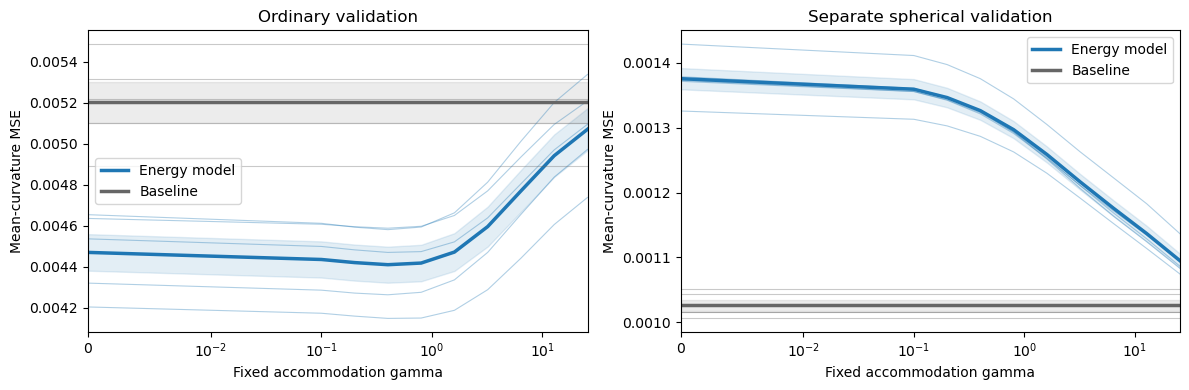

Use this run in experiments/benchmarks/energy_model_evaluation.ipynb: /home/fmoller/Projects/LearningOrganoids/GraphNN/training_results/energy_model_training/all_to_all_linear_fraction_hop1_matched_20261002_133445


In [7]:
scores=pd.DataFrame(scores)
fig,axes=plt.subplots(1,2,figsize=(12,4),squeeze=False)
for ax,role in zip(axes.flat,['val','spherical']):
    d=scores[scores.cohort==role]
    if d.empty:
        ax.text(.5,.5,'No eligible organoids',ha='center',transform=ax.transAxes);continue
    for column,label,color in [('mse','Energy model','tab:blue'),('baseline_mse','Baseline','0.4')]:
        fold_means=d.groupby(['fold','gamma'])[column].mean().reset_index()
        for fold,v in fold_means.groupby('fold'):ax.plot(v.gamma,v[column],color=color,lw=.8,alpha=.35)
        summary=fold_means.groupby('gamma')[column].agg(['mean','sem'])
        if d.fold.nunique()==1:summary['sem']=d.groupby('gamma')[column].sem()
        ax.plot(summary.index,summary['mean'],color=color,lw=2.5,label=label)
        ax.fill_between(summary.index,summary['mean']-summary['sem'],summary['mean']+summary['sem'],color=color,alpha=.12)
    if gin_scores:
        gd=pd.DataFrame(gin_scores);gd=gd[gd.cohort==role]
        if len(gd):
            ax.axhline(gd.mse.mean(),color='tab:green',lw=2,label='Depth-1 GIN')
            ax.axhspan(gd.mse.mean()-gd.mse.sem(),gd.mse.mean()+gd.mse.sem(),color='tab:green',alpha=.1)
    ax.set(xscale='symlog',xlabel='Fixed accommodation gamma',ylabel='Mean-curvature MSE',title='Ordinary validation' if role=='val' else 'Separate spherical validation')
    ax.set_xscale('symlog',linthresh=.01)
    ax.set_xlim(min(SETTINGS['gamma_grid']),max(SETTINGS['gamma_grid']));ax.legend()
fig.tight_layout();fig.savefig(RUN_DIR/'validation_mse.png',dpi=160);plt.show()
print('Use this run in experiments/benchmarks/energy_model_evaluation.ipynb:',RUN_DIR)